# FB graph

In [ ]:
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt

In [ ]:
file_path = "facebook_combined.txt"
G = nx.read_edgelist(file_path, nodetype=int)

print("Jumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())

Jumlah Node : 4039
Jumlah Edge : 88234


In [ ]:
partition = community_louvain.best_partition(G)

# Jumlah komunitas
num_communities = len(set(partition.values()))
print("Jumlah Komunitas Terdeteksi:", num_communities)

Jumlah Komunitas Terdeteksi: 16


In [ ]:
modularity = community_louvain.modularity(partition, G)
print("Modularity:", modularity)

Modularity: 0.8349638157840975


In [ ]:
from collections import defaultdict

community_groups = defaultdict(list)
for node, comm in partition.items():
    community_groups[comm].append(node)

for cid, members in community_groups.items():
    print(f"Komunitas {cid} | Jumlah anggota: {len(members)}")

Komunitas 0 | Jumlah anggota: 350
Komunitas 1 | Jumlah anggota: 433
Komunitas 8 | Jumlah anggota: 435
Komunitas 3 | Jumlah anggota: 423
Komunitas 4 | Jumlah anggota: 535
Komunitas 5 | Jumlah anggota: 324
Komunitas 7 | Jumlah anggota: 126
Komunitas 9 | Jumlah anggota: 548
Komunitas 10 | Jumlah anggota: 73
Komunitas 11 | Jumlah anggota: 237
Komunitas 12 | Jumlah anggota: 25
Komunitas 13 | Jumlah anggota: 60
Komunitas 14 | Jumlah anggota: 206
Komunitas 2 | Jumlah anggota: 226
Komunitas 6 | Jumlah anggota: 19
Komunitas 15 | Jumlah anggota: 19


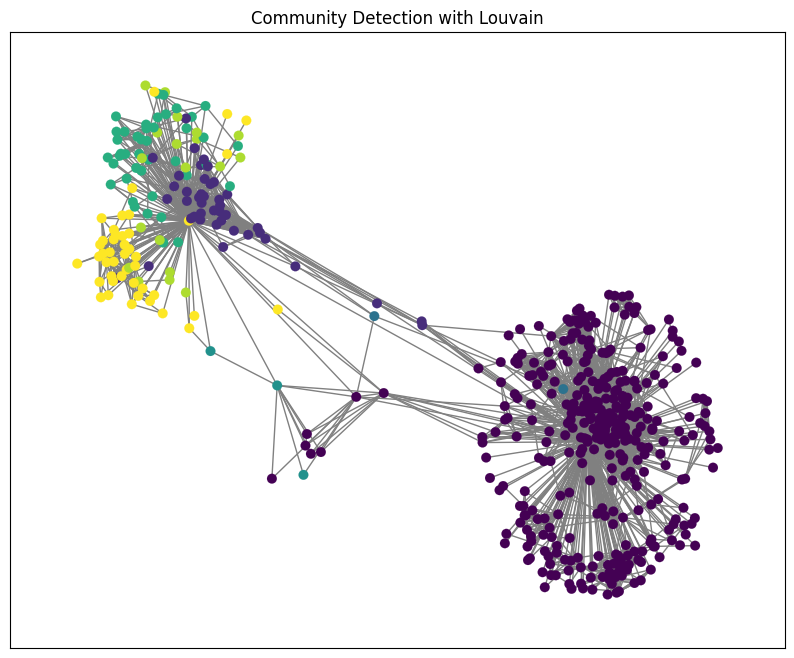

In [ ]:
sample_nodes = list(G.nodes())[:500]
H = G.subgraph(sample_nodes)

pos = nx.spring_layout(H, seed=42)
colors = [partition[n] for n in H.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx(H, pos,
                 node_color=colors,
                 node_size=50,
                 edge_color='gray',
                 linewidths=0.1,
                 with_labels=False)

plt.title("Community Detection with Louvain")
plt.show()

- Keluarkan Anggota setiap komunitas
- Gambarkan graph komnitas paling banyak
- Graph sub komunitas dari dari sub komunitas

### Menampilkan Anggota Setiap Komunitas

In [ ]:
print("=== Daftar Anggota Setiap Komunitas ===")

# Mengurutkan komunitas berdasarkan ID
sorted_communities = sorted(community_groups.items())

for cid, members in sorted_communities:
    # Menampilkan ID Komunitas dan Jumlahnya
    print(f"\nKomunitas {cid} (Total: {len(members)} node):")

    print(f"Anggota: {members}")
    print("-" * 50)

=== Daftar Anggota Setiap Komunitas ===

Komunitas 0 (Total: 350 node):
Anggota: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 21

### Visualisasi Graph Komunitas Terbesar

Komunitas Terbesar adalah ID: 9 dengan 548 node.


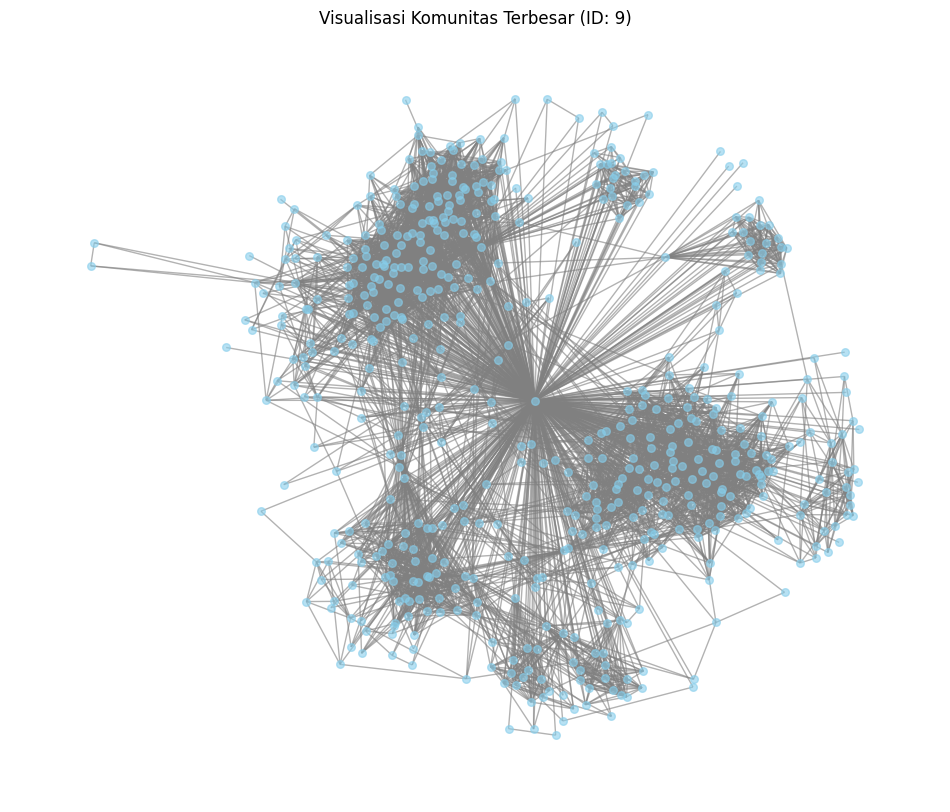

In [ ]:
# Mencari komunitas dengan anggota terbanyak
largest_community_id = max(community_groups, key=lambda x: len(community_groups[x]))
largest_community_nodes = community_groups[largest_community_id]

print(f"Komunitas Terbesar adalah ID: {largest_community_id} dengan {len(largest_community_nodes)} node.")

# Membuat Subgraph hanya untuk komunitas terbesar
G_largest = G.subgraph(largest_community_nodes)

# Menentukan layout visualisasi
pos_largest = nx.spring_layout(G_largest, seed=42, k=0.15)

plt.figure(figsize=(12, 10))
nx.draw_networkx(G_largest, pos_largest,
                 node_color='skyblue',
                 node_size=30,
                 edge_color='gray',
                 alpha=0.6,
                 with_labels=False)

plt.title(f"Visualisasi Komunitas Terbesar (ID: {largest_community_id})")
plt.axis('off')
plt.show()

### Graph Sub-Komunitas dari Komunitas Terbesar

Ditemukan 8 sub-komunitas di dalam Komunitas 9


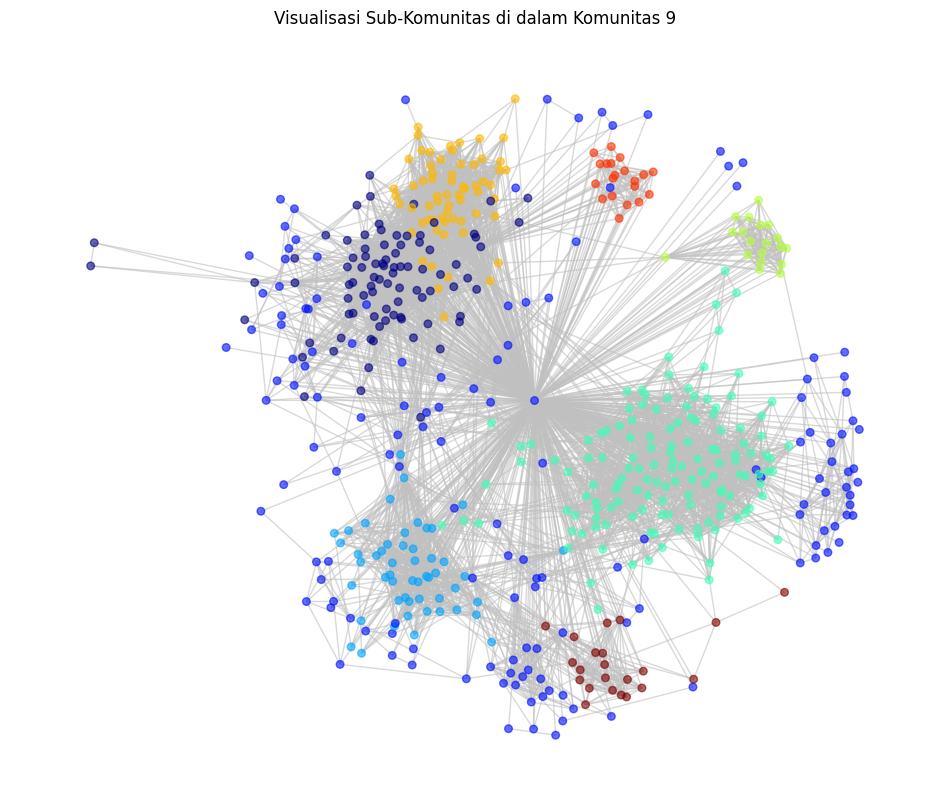

In [ ]:
# Menjalankan Louvain kembali HANYA pada subgraph komunitas terbesar
sub_partition = community_louvain.best_partition(G_largest)

# Menghitung jumlah sub-komunitas
num_sub_communities = len(set(sub_partition.values()))
print(f"Ditemukan {num_sub_communities} sub-komunitas di dalam Komunitas {largest_community_id}")

# Mewarnai node berdasarkan sub-komunitasnya
sub_colors = [sub_partition[n] for n in G_largest.nodes()]

plt.figure(figsize=(12, 10))
nx.draw_networkx(G_largest, pos_largest,
                 node_color=sub_colors,
                 node_size=30,
                 cmap=plt.cm.jet,
                 edge_color='silver',
                 alpha=0.6,
                 with_labels=False)

plt.title(f"Visualisasi Sub-Komunitas di dalam Komunitas {largest_community_id}")
plt.axis('off')
plt.show()